In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/heart_disease_uci.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [ ]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


# STEP01: DATA CLEANING

Drop Coloumns with Excessive Missing Values

In [ ]:
df_cleaned = df.drop(columns=['ca', 'thal', 'slope'])

Identify Numerical Coloumns

In [ ]:
numeric_cols = ['trestbps', 'chol', 'thalch', 'oldpeak']
for col in numeric_cols:
    df_cleaned[col].fillna(df_cleaned[col].median(), inplace=True)

<ipython-input-55-39a6825ffaf3>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned[col].fillna(df_cleaned[col].median(), inplace=True)


Identify Catogorical Coloumns

In [ ]:
categorical_cols = ['fbs', 'restecg', 'exang']
for col in categorical_cols:
    df_cleaned[col].fillna(df_cleaned[col].mode()[0], inplace=True)

<ipython-input-56-977ce6309a61>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned[col].fillna(df_cleaned[col].mode()[0], inplace=True)
<ipython-input-56-977ce6309a61>:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cleaned[col].fillna(df_cleaned[col].mode()[0], inplace=True)


Remove Duplicates

In [ ]:
before_dedup = df_cleaned.shape[0]
df_cleaned.drop_duplicates(inplace=True)
after_dedup = df_cleaned.shape[0]
duplicates_removed = before_dedup - after_dedup

One-hot encode nominal categorical variables

In [ ]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['cp', 'restecg'], drop_first=True)

One-Hot Encoding is suitable for nominal features with multiple categories as it avoids implying an ordinal relationship between the categories.
Using one-hot encoding is preferred over label encoding for these columns. If we used label encoding, the model might interpret the assigned numerical values as having an ordered relationship (e.g., that category 2 is "greater" than category 1)

**Feature scaling using StandardScaler**

Standard Scalar is more suitable for ML models and normally distributed data. Considering this data set is normally distributed Standard scalar would be an approprite Choice

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
df_cleaned[scaled_cols] = scaler.fit_transform(df_cleaned[scaled_cols])

In [ ]:
df_cleaned_info = df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        920 non-null    int64  
 1   age                       920 non-null    float64
 2   sex                       920 non-null    int64  
 3   dataset                   920 non-null    object 
 4   trestbps                  920 non-null    float64
 5   chol                      920 non-null    float64
 6   fbs                       0 non-null      float64
 7   thalch                    920 non-null    float64
 8   exang                     0 non-null      float64
 9   oldpeak                   920 non-null    float64
 10  num                       920 non-null    int64  
 11  cp_atypical angina        920 non-null    bool   
 12  cp_non-anginal            920 non-null    bool   
 13  cp_typical angina         920 non-null    bool   
 14  restecg_no

In [ ]:
duplicates_removed, df_cleaned.head()

(0,
    id       age  sex    dataset  trestbps      chol  fbs    thalch  exang  \
 0   1  1.007386    1  Cleveland  0.705176  0.303643  NaN  0.489727    NaN   
 1   2  1.432034    1  Cleveland  1.518569  0.789967  NaN -1.181478    NaN   
 2   3  1.432034    1  Cleveland -0.650479  0.266939  NaN -0.345875    NaN   
 3   4 -1.752828    1  Cleveland -0.108217  0.459634  NaN  1.961979    NaN   
 4   5 -1.328180    0  Cleveland -0.108217  0.037541  NaN  1.365120    NaN   
 
     oldpeak  num  cp_atypical angina  cp_non-anginal  cp_typical angina  \
 0  1.368109    0               False           False               True   
 1  0.611589    2               False           False              False   
 2  1.651804    1               False           False              False   
 3  2.502889    0               False            True              False   
 4  0.517024    0                True           False              False   
 
    restecg_normal  restecg_st-t abnormality  
 0           False   

# STEP 02 DATA VISUALIZATION and EXPLORATORY DATA ANALYSIS

**Feature Distribution Assessment**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
df_visual = df.copy()
df_visual['fbs'] = df_visual['fbs'].map({'True': 1, 'False': 0})
df_visual['exang'] = df_visual['exang'].map({'True': 1, 'False': 0})


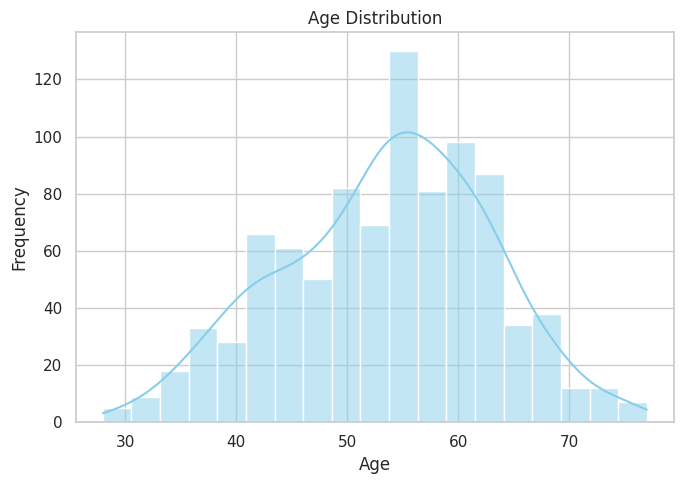

In [ ]:
fig_age, ax_age = plt.subplots(figsize=(7, 5))
sns.histplot(df_visual['age'], kde=True, ax=ax_age, color='skyblue')
ax_age.set_title('Age Distribution')
ax_age.set_xlabel('Age')
ax_age.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

# Age Distribution
*   **Central Tendency:** The distribution is unimodal, with the peak around the late 50s to early 60s. This suggests that a significant portion of the dataset comprises individuals in this age range. The median and mean are likely close to this peak, indicating the typical age of participants.
*   **Spread:** The age ranges from roughly 30 to over 70, showing a considerable spread. The standard deviation would likely be moderate.
*   **Skewness:** The distribution appears slightly left-skewed, meaning there's a tail extending more towards younger ages. This suggests there are fewer younger individuals in the dataset compared to the peak age group.

The dataset is primarily focused on middle-aged (35 to 49) and older adults (50 to 65), which is consistent with the demographic at higher risk for heart disease.


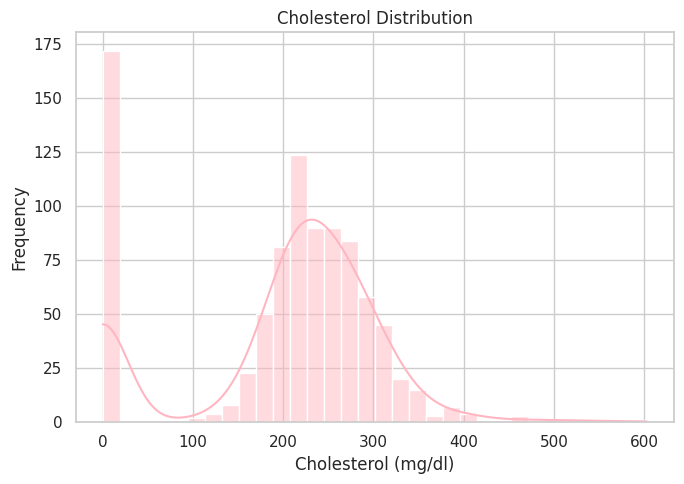

In [ ]:
fig_chol, ax_chol = plt.subplots(figsize=(7, 5))
sns.histplot(df_visual['chol'], kde=True, ax=ax_chol, color='lightpink')
ax_chol.set_title('Cholesterol Distribution')
ax_chol.set_xlabel('Cholesterol (mg/dl)')
ax_chol.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

**Cholesterol (chol) Distribution:**
*   **Central Tendency:** The distribution is somewhat bell-shaped, with a peak around 200-250 mg/dl. This represents the most common cholesterol levels in the dataset.
*   **Spread:** There's a significant spread in cholesterol levels, ranging from below 0 to over 500 mg/dl. This wide range indicates considerable variation in cholesterol among individuals.
*   **Skewness:** The distribution appears slightly right-skewed, with a tail extending towards higher cholesterol values. This suggests there are some individuals with very high cholesterol levels.

The dataset includes individuals with a wide spectrum of cholesterol levels, including some with potentially unhealthy high levels, which is a known risk factor for heart disease.

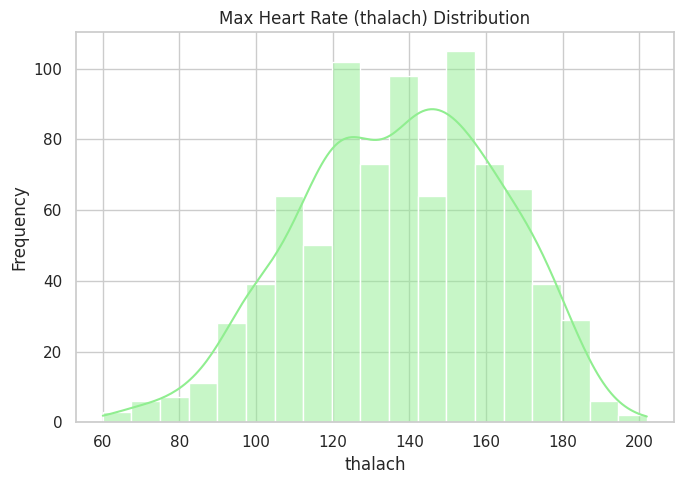

In [ ]:
fig_thalach, ax_thalach = plt.subplots(figsize=(7, 5))
sns.histplot(df_visual['thalch'], kde=True, ax=ax_thalach, color='lightgreen')
ax_thalach.set_title('Max Heart Rate (thalach) Distribution')
ax_thalach.set_xlabel('thalach')
ax_thalach.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

**Max Heart Rate (thalach) Distribution:**
*   **Central Tendency:** The distribution is roughly symmetrical and unimodal, with a peak around 150-160 bpm. This indicates the typical maximum heart rate achieved by individuals during exercise in the dataset.
*   **Spread:** The range of thalach is from below 60 to 200 bpm. The spread is moderate.
*   **Skewness:** The distribution appears fairly symmetrical, with no significant skewness.

The dataset contains a range of maximum heart rates, providing information on an individual's exercise capacity, which can be relevant to heart health.

<ipython-input-34-a9a999596f9d>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='num', data=df_visual, ax=ax_target, palette='viridis')


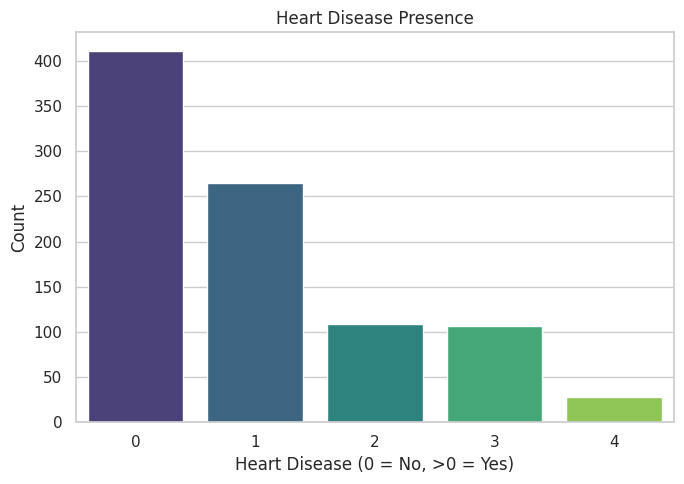

In [ ]:
fig_target, ax_target = plt.subplots(figsize=(7, 5))
sns.countplot(x='num', data=df_visual, ax=ax_target, palette='viridis')
ax_target.set_title('Heart Disease Presence')
ax_target.set_xlabel('Heart Disease (0 = No, >0 = Yes)')
ax_target.set_ylabel('Count')
plt.tight_layout()
plt.show()

Heart Disease Presence (target) Distribution:**

*   **Central Tendency:** This is a categorical variable representing the presence or absence of heart disease. Central tendency measures like mean or median are not applicable.
*   **Spread:** The spread is simply the distribution of counts across the categories (0, 1, 2, 3, 4).
*   **Skewness:** The distribution is heavily skewed towards '0' (No Heart Disease), indicating that a larger proportion of the dataset consists of individuals without heart disease compared to those with varying degrees of heart disease (1, 2, 3, 4).

The dataset is imbalanced with respect to the target variable. It critical characteristic of the dataset. It means that models trained on this data might be biased towards predicting "no heart disease."

**Inter-Feature Relationship Mapping**

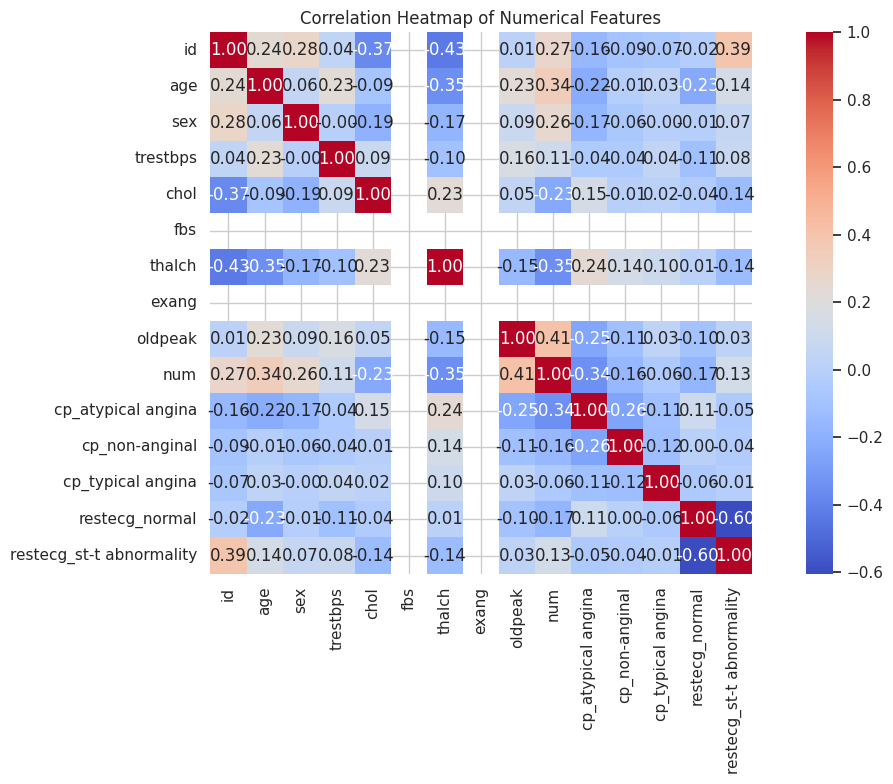


Top 3 features with the most significant correlations with the target 'num':
oldpeak               0.411588
thalch               -0.349173
cp_atypical angina   -0.343266
Name: num, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
target_variable = 'num'
correlation_matrix = df_cleaned.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

if target_variable in correlation_matrix.columns:
    target_correlations = correlation_matrix[target_variable].drop(target_variable)
    top_3_features = target_correlations.abs().sort_values(ascending=False).head(3)
    print(f"\nTop 3 features with the most significant correlations with the target '{target_variable}':")
    print(target_correlations.loc[top_3_features.index])
else:
    print(f"Target variable '{target_variable}' not found in the dataframe columns.")

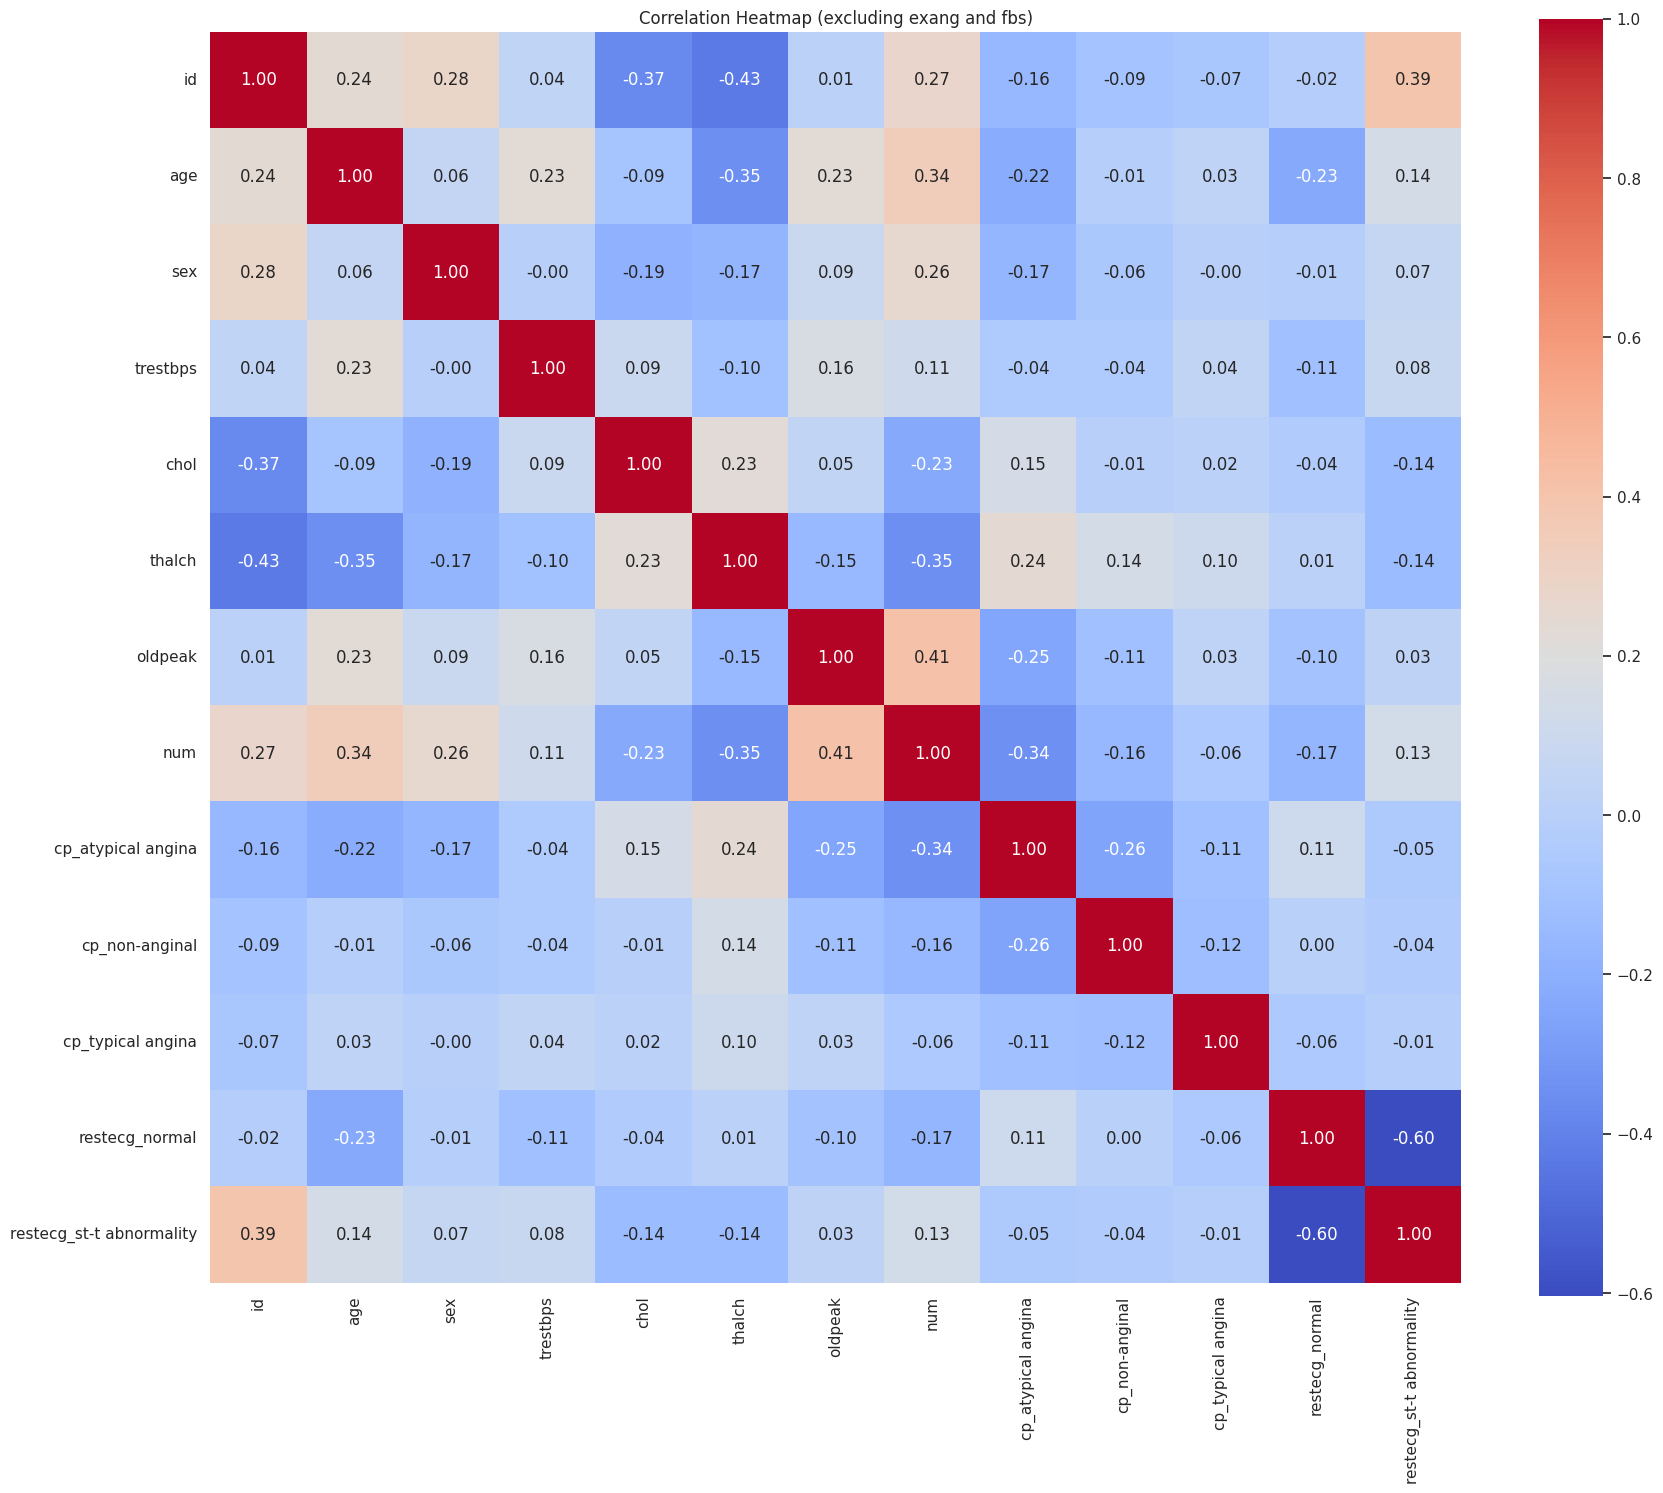

In [ ]:
correlation_matrix_dropped = correlation_matrix.drop(columns=['exang', 'fbs']).drop(index=['exang', 'fbs'])
plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix_dropped, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Heatmap (excluding exang and fbs)")
plt.tight_layout()
plt.show()

Discuss possible reasons or hypotheses behind these associations in the context of cardiovascular health.

Oldpeak

First feathure is Oldpeak," or ST-segment depression induced by exercise relative to rest, is a key indicator in assessing cardiovascular health, particularly concerning coronary artery disease (CAD) These old peak can be a risk factor for CAD and is associated with a higher prevalence of severe coronary disease.

Thalch

This feature demosntartes a lower maximum heart rate achieved, or a lower target heart rate zone during exercise, can be associated with an increased risk of cardiovascular diseases, such as coronary artery disease.

cp_atypical angina

Patients with atypical angina indicate a higher likelihood of coronary artery disease, but it's not as strong as the association seen with typical angina.  


**Comparative Analysis by Condition Status**

<ipython-input-48-61ad0fe986ac>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_variable, y='age', data=df_cleaned, ax=axes[0], palette='viridis')
<ipython-input-48-61ad0fe986ac>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_variable, y='trestbps', data=df_cleaned, ax=axes[1], palette='viridis')
<ipython-input-48-61ad0fe986ac>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_variable, y='chol', data=df_cleaned, ax=axes[2], palette='viridis')


Text(0, 0.5, 'Cholesterol (chol)')

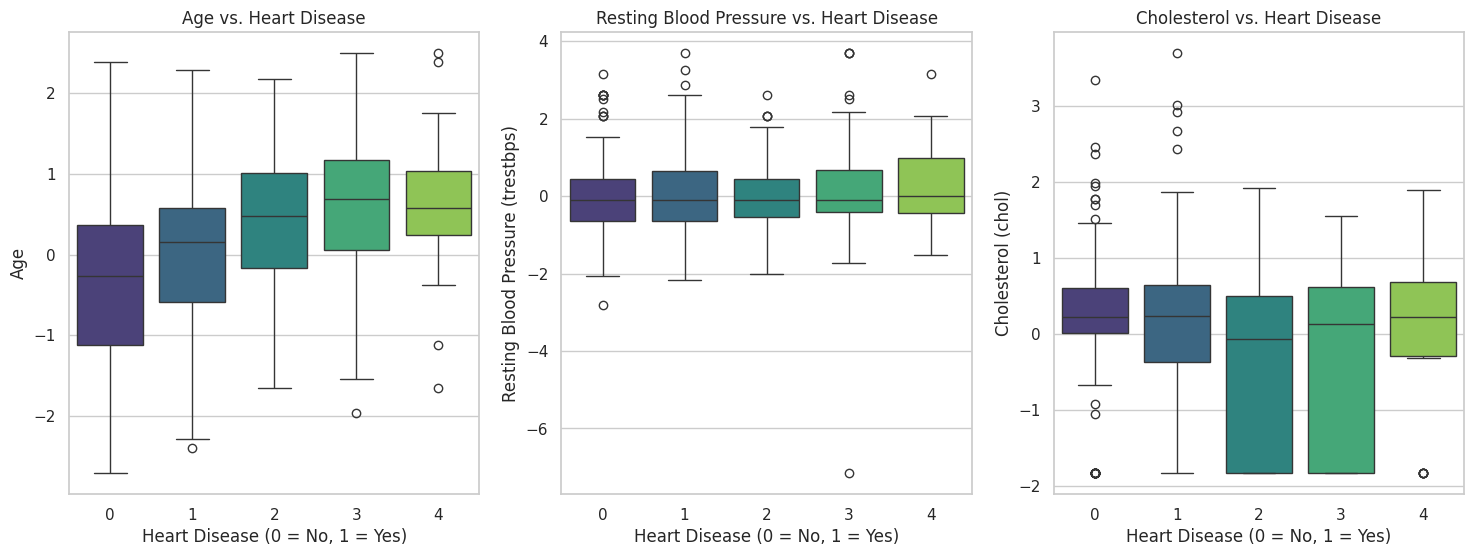

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

sns.boxplot(x=target_variable, y='age', data=df_cleaned, ax=axes[0], palette='viridis')
axes[0].set_title('Age vs. Heart Disease')
axes[0].set_xlabel('Heart Disease (0 = No, 1 = Yes)')
axes[0].set_ylabel('Age')
sns.boxplot(x=target_variable, y='trestbps', data=df_cleaned, ax=axes[1], palette='viridis')
axes[1].set_title('Resting Blood Pressure vs. Heart Disease')
axes[1].set_xlabel('Heart Disease (0 = No, 1 = Yes)')
axes[1].set_ylabel('Resting Blood Pressure (trestbps)')

sns.boxplot(x=target_variable, y='chol', data=df_cleaned, ax=axes[2], palette='viridis')
axes[2].set_title('Cholesterol vs. Heart Disease')
axes[2].set_xlabel('Heart Disease (0 = No, 1 = Yes)')
axes[2].set_ylabel('Cholesterol (chol)')

**Age vs. Heart Disease**

There is a distinct difference in the median age between the two groups. Individuals with heart disease (target=1) tend to have a higher median age compared to those without heart disease (target=0).

There is also some overlap in the age ranges, indicating that age alone is not a perfect predictor, but older individuals are more likely to have heart disease in this dataset.

The box plot for target=1 appears to have a wider spread (larger interquartile range), suggesting more variability in age within the heart disease group.

**Resting Blood Pressure (trestbps) vs. Heart Disease**

The difference in median resting blood pressure between the two groups appears less pronounced than the age.

There is significant overlap in the distributions of trestbps for both groups.

While the median trestbps for individuals with heart disease might be slightly higher, the distributions are quite similar, suggesting that resting blood pressure in isolation might not be a strong differentiator between the two classes in this dataset.
The dotted points denotes that there are outliers in both groups.

**Cholesterol (chol) vs. Heart Disease:**

 Similatr to the Blood Pressure here is a large overlap in the cholesterol levels between the two groups.

The median cholesterol levels appear very close for both groups.

The dots represents that there are several outliers in both groups, particularly in the 'No Heart Disease' group, indicating some individuals without heart disease have very high cholesterol.

This overlap and the similar medians suggest that cholesterol, by itself, might not be a highly distinguishing feature for predicting heart disease in this dataset.



The patterns observed suggest that **age** is likely to be a more informative feature for distinguishing between the two classes compared to trestbps and chol. The clearer separation in age distributions, especially the difference in medians, indicates that a model could leverage age more effectively for classification.
The substantial overlap in trestbps and chol distributions for the two target categories implies that these features alone might not have a strong discriminatory power. A model relying solely on these features would likely struggle to accurately separate the classes. trestbps and chol show more overlap, indicating they might be less discriminative on their own but could still contribute to the model's performance when considered alongside other features.

# Model Training, Evaluation, and Improvement

**RELOAD THE DATA**

In [ ]:
df_raw = pd.read_csv("/content/heart_disease_uci.csv")
df_raw.rename(columns={'num': 'target'}, inplace=True)
df_clean = df_raw.drop(columns=['id', 'dataset'])
df_clean = df_clean.dropna()

from sklearn.preprocessing import LabelEncoder
binary_cols = ['sex', 'fbs', 'exang']
for col in binary_cols:
    df_clean[col] = LabelEncoder().fit_transform(df_clean[col].astype(str))
df_clean = pd.get_dummies(df_clean, columns=['cp', 'restecg', 'slope', 'thal'], drop_first=True)
df_clean['target'] = df_clean['target'].apply(lambda x: 0 if x == 0 else 1)
df_clean.head()

,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,ca,target,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,1,145.0,233.0,1,150.0,0,2.3,0.0,0,False,False,True,False,False,False,False,False,False
1,67,1,160.0,286.0,0,108.0,1,1.5,3.0,1,False,False,False,False,False,True,False,True,False
2,67,1,120.0,229.0,0,129.0,1,2.6,2.0,1,False,False,False,False,False,True,False,False,True
3,37,1,130.0,250.0,0,187.0,0,3.5,0.0,0,False,True,False,True,False,False,False,True,False
4,41,0,130.0,204.0,0,172.0,0,1.4,0.0,0,True,False,False,False,False,False,True,True,False


**Classification Model (Random Classifier)**


The Logistic Regression was chosen considering the nature of the problem because this is a binary classification problem (Yes or No) in terms of whther patient has a heart disease or not. Logistic Regression provides a straightforward and effective starting point for building a predictive model for heart disease.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

(0.8222222222222222, 0.8421052631578947, 0.7619047619047619, 0.8)

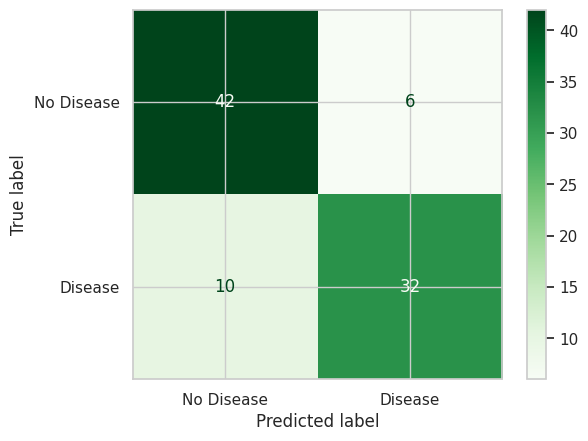

In [ ]:
y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)

ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["No Disease", "Disease"]).plot(cmap="Greens")

accuracy_rf, precision_rf, recall_rf, f1_rf

Different classification algorithm (Logistic Regression)

In [ ]:
X = df_clean.drop(columns='target')
y = df_clean['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
model = LogisticRegression(max_iter=100)
model.fit(X_train, y_train)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

(0.8555555555555555,
 0.8918918918918919,
 0.7857142857142857,
 0.8354430379746836)

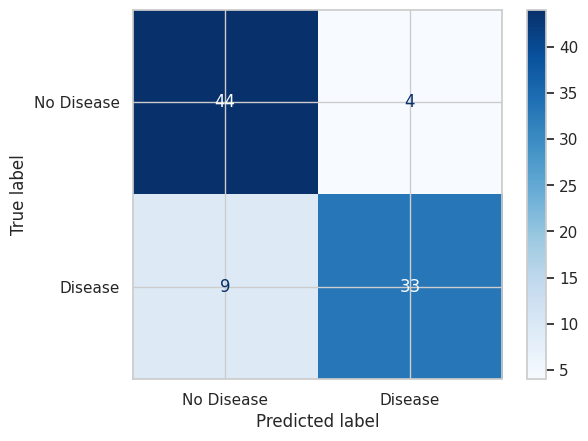

In [ ]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Disease"]).plot(cmap="Blues")

accuracy, precision, recall, f1


Random classifies showed an accuracy 83% and Logistic Regression showed accuracy 85% therefoe logistic regression is an appropriate choice. The Logistic Regression was chosen considering the nature of the problem because this is a binary classification problem (Yes or No) in terms of whther patient has a heart disease or not. Logistic Regression provides a straightforward and effective starting point for building a predictive model for heart disease.

In [ ]:
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix Interpretation:")
print(f"True Negatives (TN): {tn} - Correctly predicted as No Disease")
print(f"False Positives (FP): {fp} - Incorrectly predicted as Disease (Type I Error)")
print(f"False Negatives (FN): {fn} - Incorrectly predicted as No Disease (Type II Error)")
print(f"True Positives (TP): {tp} - Correctly predicted as Disease")


Confusion Matrix Interpretation:
True Negatives (TN): 44 - Correctly predicted as No Disease
False Positives (FP): 4 - Incorrectly predicted as Disease (Type I Error)
False Negatives (FN): 9 - Incorrectly predicted as No Disease (Type II Error)
True Positives (TP): 33 - Correctly predicted as Disease


In the Case of False positive (Type I Error) these are individuals predicted to have heart disease but do not.

**Clinical Implication:**

Due to false identification these patients might undergo unnecessary further testing (e.g., stress tests, angiography), leading to anxiety, stress, and potential risks from invasive procedures. This also strains healthcare resources."

**Business Implications:**

The overall costs might increase for the healthcare provider and the patient as well due to unnecessary tests and consultations. Potential for decreased patient trust if initial diagnosis is wrong.

In False Negate Cases these are individuals predicted to NOT have heart disease but actually do.

**Clinical Implications**

These patients will not receive timely diagnosis and treatment for their condition. This can lead to disease progression and potentially irreversible damage."

**Business Implications**
The institution can face potential legal liability for misdiagnosis and damage to the institution's reputation.

In a medical scenario like heart disease prediction, False Negatives (FN) are generally considered more critical than False Positives (FP). Missing a heart disease diagnosis (FN) has potentially life-threatening consequences for the patient, while a false positive, while undesirable and costly, typically results in further investigation rather than missed treatment.")

**Improvements to the model** (Logistic Regression)

HyperParamete Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

grid_search = GridSearchCV(LogisticRegression(max_iter=100, random_state=42), param_grid, cv=5, scoring='recall')

grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
best_recall = grid_search.best_score_
print(f"Best parameters found: {best_params}")
print(f"Best cross-validation recall: {best_recall:.4f}")

Best parameters found: {'C': 10, 'solver': 'lbfgs'}
Best cross-validation recall: 0.7868


Cross Validation

In [ ]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model, X, y, cv=5)
print("Cross-validation scores:", cv_scores)
print("Mean cross-validation score:", cv_scores.mean())

Cross-validation scores: [0.86666667 0.88333333 0.8        0.81666667 0.79661017]
Mean cross-validation score: 0.8326553672316382
